In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv

load_dotenv('../.env')

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Setup complete")

Setup complete


In [2]:
# Load price data
price_df = pd.read_csv('../data/raw/AAPL/price_data.csv')
price_df['date'] = pd.to_datetime(price_df['date'], utc=True)

# Load enriched news
news_df = pd.read_csv('../data/processed/AAPL/news_enriched.csv')
news_df['published_at'] = pd.to_datetime(news_df['published_at'], utc=True, errors='coerce')

print(f"Price data: {len(price_df)} rows | {price_df['date'].min().date()} to {price_df['date'].max().date()}")
print(f"News data:  {len(news_df)} rows | {news_df['published_at'].min().date()} to {news_df['published_at'].max().date()}")

price_df.head()

Price data: 250 rows | 2025-05-09 to 2026-05-07
News data:  96 rows | 2026-05-08 to 2026-05-10


,date,open,high,low,close,volume,dividends,stock_splits,ticker,price_ma5,price_ma20,ma_crossover,volume_change_pct,rsi_14,daily_return,price_direction
0,2025-05-09 04:00:00+00:00,198.136434,199.669744,196.682763,197.668472,36453900,0.00,0.0,AAPL,197.668472,197.668472,0,0.000000,100.000000,0.000000,1
1,2025-05-12 04:00:00+00:00,210.329959,210.629052,206.122761,210.150497,63775800,0.26,0.0,AAPL,203.909485,203.909485,0,74.949182,100.000000,6.314626,1
2,2025-05-13 04:00:00+00:00,209.791581,212.752572,208.365927,212.283997,51909300,0.00,0.0,AAPL,206.700989,206.700989,0,-18.606587,100.000000,1.015224,0
3,2025-05-14 04:00:00+00:00,211.785494,213.290922,209.941116,211.685806,49325800,0.00,0.0,AAPL,207.947193,207.947193,0,-4.976950,96.068085,-0.281788,0
4,2025-05-15 04:00:00+00:00,210.310004,212.313916,208.904278,210.808487,45029500,0.00,0.0,AAPL,208.519452,208.519452,0,-8.710046,90.830237,-0.414444,0


In [3]:
fig = go.Figure()

fig.add_trace(go.Candlestick(
    x     = price_df['date'],
    open  = price_df['open'],
    high  = price_df['high'],
    low   = price_df['low'],
    close = price_df['close'],
    name  = 'AAPL',
))

fig.update_layout(
    title      = 'AAPL Price — Last 12 Months',
    xaxis_title = 'Date',
    yaxis_title = 'Price (USD)',
    height     = 450,
    xaxis_rangeslider_visible = False,
)

fig.show()

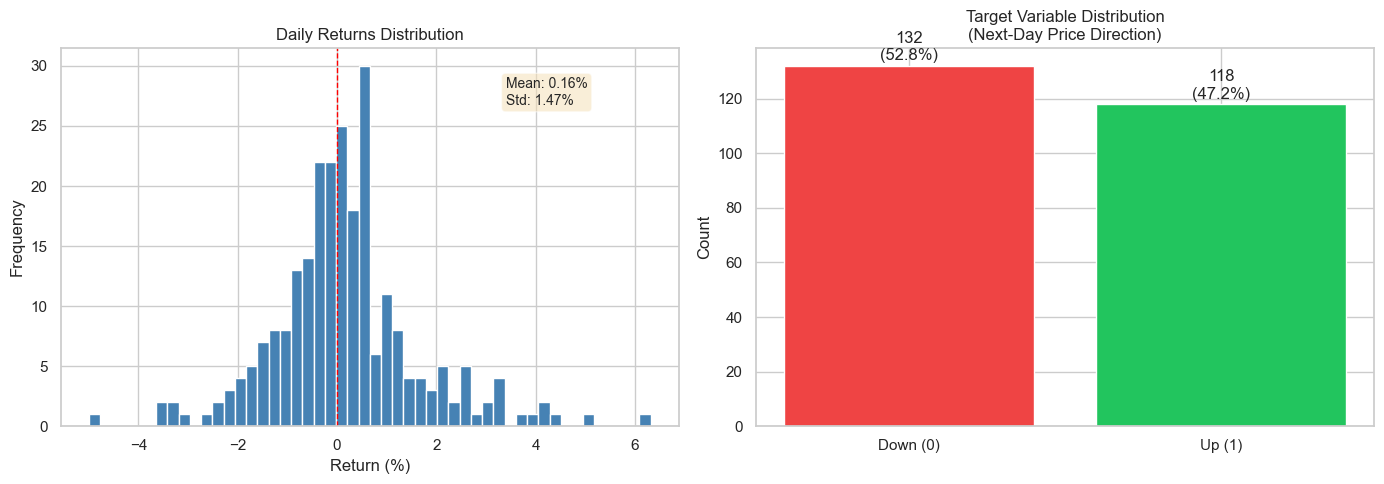


Class balance: 52.8% up days, 47.2% down days


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily returns histogram
axes[0].hist(price_df['daily_return'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Daily Returns Distribution')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')

# Add stats annotation
mean_ret = price_df['daily_return'].mean()
std_ret  = price_df['daily_return'].std()
axes[0].annotate(
    f'Mean: {mean_ret:.2f}%\nStd: {std_ret:.2f}%',
    xy=(0.72, 0.85), xycoords='axes fraction',
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

# Target variable distribution
target_counts = price_df['price_direction'].value_counts()
axes[1].bar(
    ['Down (0)', 'Up (1)'],
    target_counts.values,
    color=['#ef4444', '#22c55e'],
    edgecolor='white',
)
axes[1].set_title('Target Variable Distribution\n(Next-Day Price Direction)')
axes[1].set_ylabel('Count')

for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + 2, f'{v}\n({v/len(price_df):.1%})', ha='center')

plt.tight_layout()
plt.show()

print(f"\nClass balance: {target_counts[1]/len(price_df):.1%} up days, {target_counts[0]/len(price_df):.1%} down days")

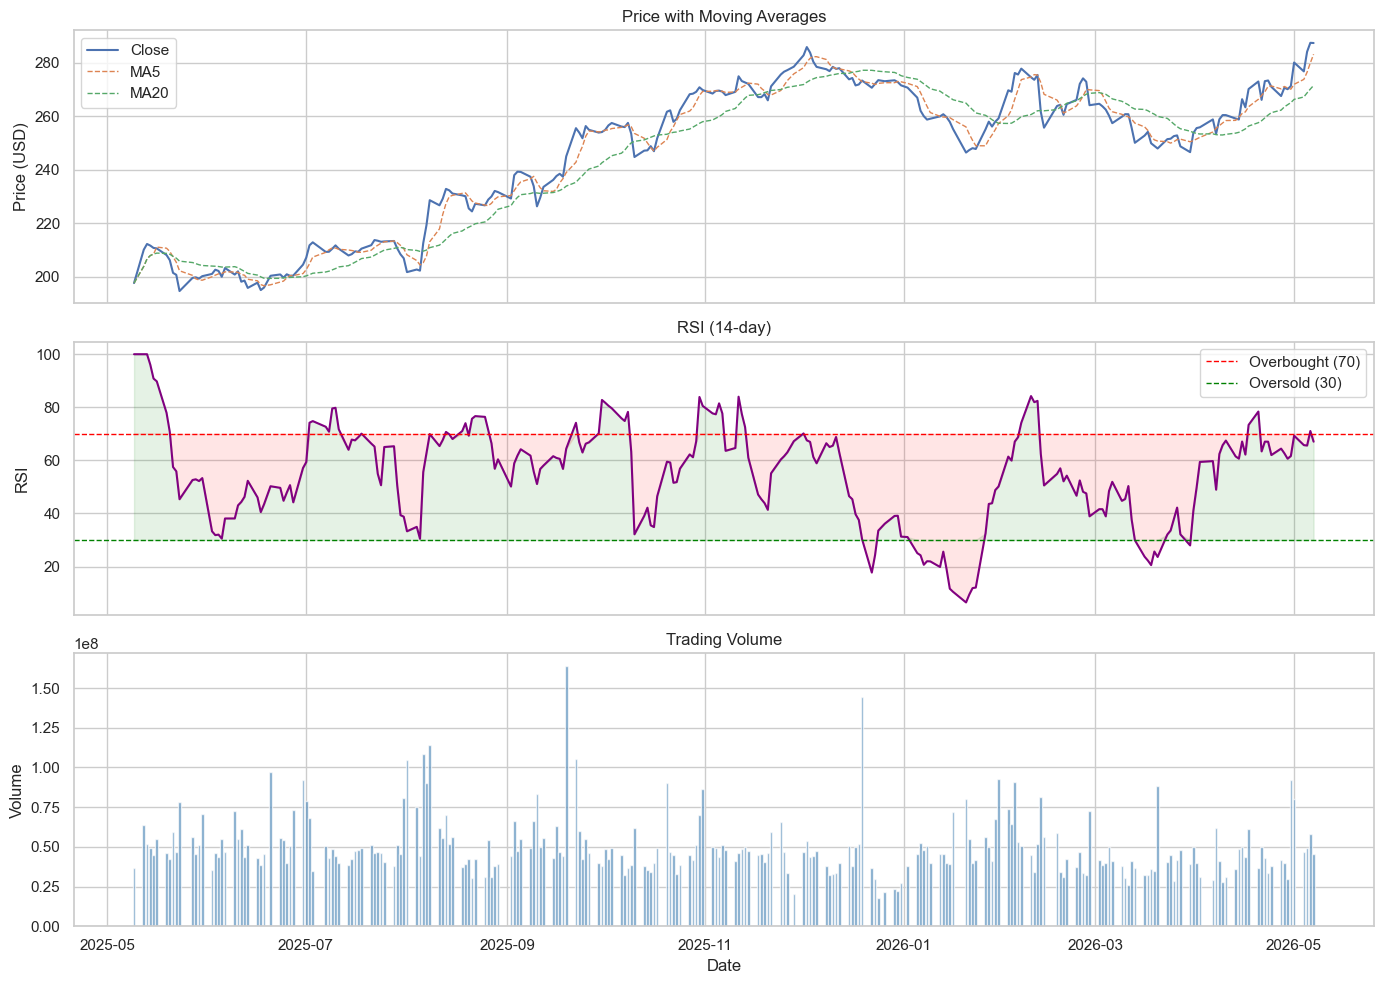

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price with moving averages
axes[0].plot(price_df['date'], price_df['close'],   label='Close',  linewidth=1.5)
axes[0].plot(price_df['date'], price_df['price_ma5'],  label='MA5',  linewidth=1, linestyle='--')
axes[0].plot(price_df['date'], price_df['price_ma20'], label='MA20', linewidth=1, linestyle='--')
axes[0].set_title('Price with Moving Averages')
axes[0].legend()
axes[0].set_ylabel('Price (USD)')

# RSI
axes[1].plot(price_df['date'], price_df['rsi_14'], color='purple', linewidth=1.5)
axes[1].axhline(70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
axes[1].fill_between(price_df['date'], 70, price_df['rsi_14'].clip(upper=70), alpha=0.1, color='red')
axes[1].fill_between(price_df['date'], 30, price_df['rsi_14'].clip(lower=30), alpha=0.1, color='green')
axes[1].set_title('RSI (14-day)')
axes[1].set_ylabel('RSI')
axes[1].legend()

# Volume
axes[2].bar(price_df['date'], price_df['volume'], color='steelblue', alpha=0.7)
axes[2].set_title('Trading Volume')
axes[2].set_ylabel('Volume')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

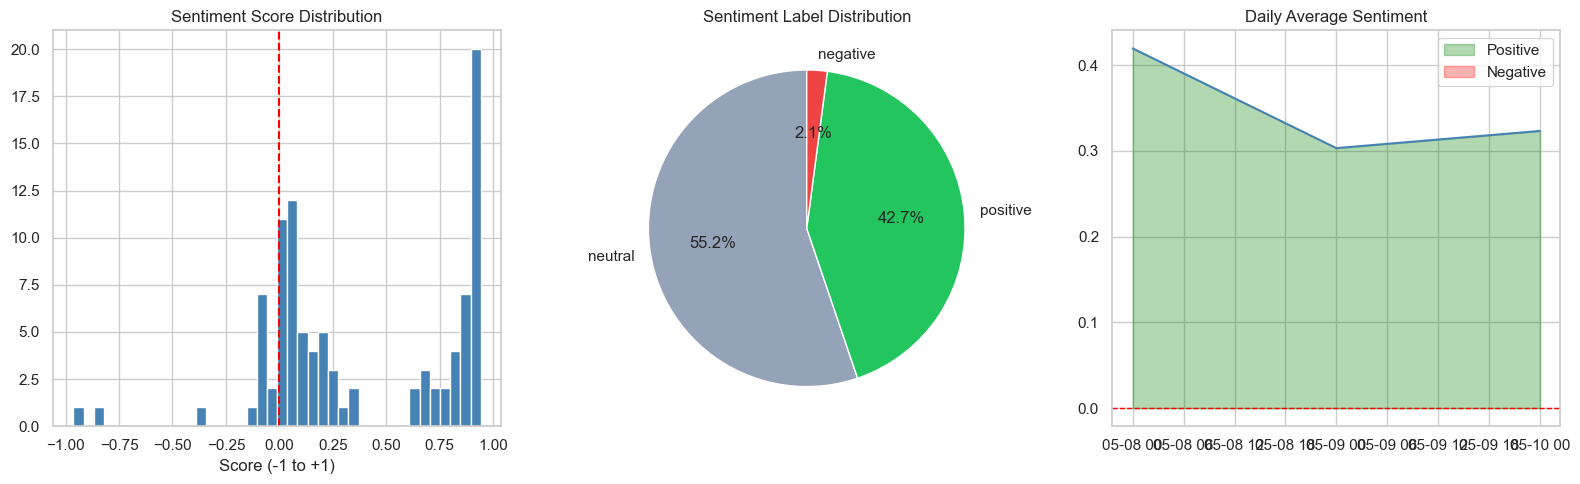

In [6]:
if 'sentiment_score' in news_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Score distribution
    axes[0].hist(news_df['sentiment_score'].dropna(), bins=40,
                 color='steelblue', edgecolor='white')
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].set_title('Sentiment Score Distribution')
    axes[0].set_xlabel('Score (-1 to +1)')

    # Label distribution
    if 'sentiment_label' in news_df.columns:
        label_counts = news_df['sentiment_label'].value_counts()
        colors = {'positive': '#22c55e', 'negative': '#ef4444', 'neutral': '#94a3b8'}
        axes[1].pie(
            label_counts.values,
            labels    = label_counts.index,
            colors    = [colors.get(l, 'gray') for l in label_counts.index],
            autopct   = '%1.1f%%',
            startangle = 90,
        )
        axes[1].set_title('Sentiment Label Distribution')

    # Sentiment over time
    news_df['date'] = news_df['published_at'].dt.date
    daily_sent = news_df.groupby('date')['sentiment_score'].mean().reset_index()
    axes[2].plot(daily_sent['date'], daily_sent['sentiment_score'],
                 color='steelblue', linewidth=1.5)
    axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[2].fill_between(
        daily_sent['date'],
        0, daily_sent['sentiment_score'],
        where  = daily_sent['sentiment_score'] > 0,
        alpha  = 0.3, color='green', label='Positive'
    )
    axes[2].fill_between(
        daily_sent['date'],
        0, daily_sent['sentiment_score'],
        where  = daily_sent['sentiment_score'] < 0,
        alpha  = 0.3, color='red', label='Negative'
    )
    axes[2].set_title('Daily Average Sentiment')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Building feature matrix...
2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Daily sentiment: 3 rows
2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Price date range: 2025-05-09 to 2026-05-07
2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Sentiment date range: 2026-05-08 to 2026-05-10
2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Rows after merge: 250
2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Merge complete | price rows: 250 | sentiment rows: 3 | merged rows: 250
2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Target distribution: {1: 0.528, 0: 0.472}
2026-05-13 12:34:38 | INFO     | src.ml.feature_engineering | Feature matrix ready | rows=250 | features=11 | target_col=price_direction


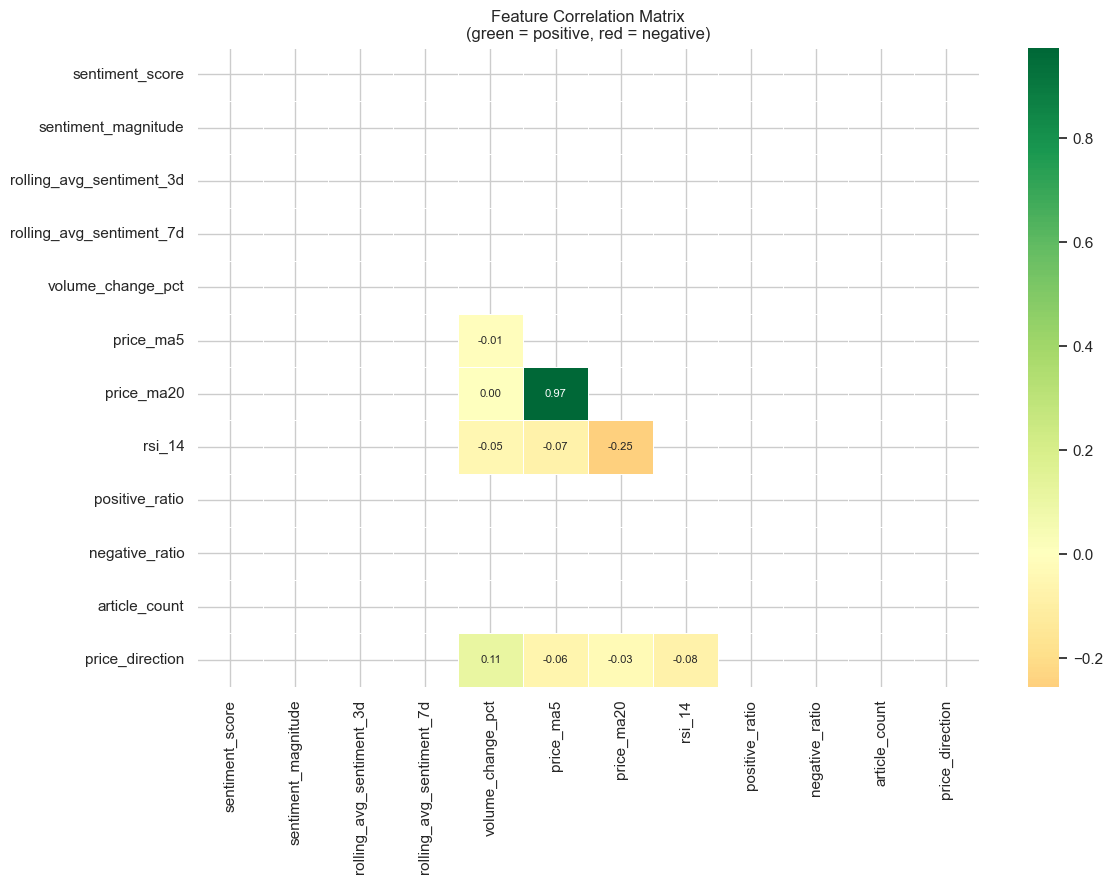


Feature correlations with price_direction:
volume_change_pct           0.110
rsi_14                     -0.076
price_ma5                  -0.061
price_ma20                 -0.035
sentiment_score               NaN
sentiment_magnitude           NaN
rolling_avg_sentiment_3d      NaN
rolling_avg_sentiment_7d      NaN
positive_ratio                NaN
negative_ratio                NaN
article_count                 NaN


In [7]:
from src.utils.constants import FEATURE_COLS, TARGET_COL
from src.ml.feature_engineering import build_feature_matrix

feature_df = build_feature_matrix(price_df, news_df)

available = [c for c in FEATURE_COLS + [TARGET_COL] if c in feature_df.columns]
corr = feature_df[available].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask       = mask,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdYlGn',
    center     = 0,
    linewidths = 0.5,
    annot_kws  = {'size': 8},
)
plt.title('Feature Correlation Matrix\n(green = positive, red = negative)')
plt.tight_layout()
plt.show()

# Most correlated features with target
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print("\nFeature correlations with price_direction:")
print(target_corr.round(3).to_string())

In [8]:
print("=" * 55)
print("EDA SUMMARY — AAPL")
print("=" * 55)

print(f"\n📈 PRICE")
print(f"   Period:        {price_df['date'].min().date()} → {price_df['date'].max().date()}")
print(f"   Price range:   ${price_df['close'].min():.2f} → ${price_df['close'].max():.2f}")
print(f"   Avg daily ret: {price_df['daily_return'].mean():.3f}%")
print(f"   Volatility:    {price_df['daily_return'].std():.3f}%")
print(f"   Up days:       {price_df['price_direction'].mean():.1%}")

if 'sentiment_score' in news_df.columns:
    print(f"\n📰 SENTIMENT")
    print(f"   Articles:      {len(news_df)}")
    print(f"   Avg score:     {news_df['sentiment_score'].mean():+.3f}")
    print(f"   Positive:      {(news_df['sentiment_label']=='positive').mean():.1%}")
    print(f"   Negative:      {(news_df['sentiment_label']=='negative').mean():.1%}")
    print(f"   Neutral:       {(news_df['sentiment_label']=='neutral').mean():.1%}")

if 'feature_df' in dir():
    print(f"\n🤖 FEATURE MATRIX")
    print(f"   Rows:          {len(feature_df)}")
    print(f"   Features:      {len(available)-1}")
    print(f"   Top feature:   {target_corr.index[0]} (r={target_corr.iloc[0]:.3f})")

print("=" * 55)

EDA SUMMARY — AAPL

📈 PRICE
   Period:        2025-05-09 → 2026-05-07
   Price range:   $194.68 → $287.51
   Avg daily ret: 0.161%
   Volatility:    1.467%
   Up days:       52.8%

📰 SENTIMENT
   Articles:      96
   Avg score:     +0.376
   Positive:      42.7%
   Negative:      2.1%
   Neutral:       55.2%

🤖 FEATURE MATRIX
   Rows:          250
   Features:      11
   Top feature:   volume_change_pct (r=0.110)
